<img src="../img/viu_logo.png" width="200">

# 01MIAR - Actividad Whitepapers
Autor: Mª Carmen Copé Soler

## Motivación

Mi interés en este artículo surge de la necesidad de comprender cómo los métodos probabilísticos, ampliamente utilizados en Inteligencia Artificial, se aplican en contextos reales donde la incertidumbre es un factor crítico. PySTRA representa un ejemplo claro de cómo las técnicas computacionales avanzadas pueden integrarse en la ingeniería estructural para mejorar la fiabilidad y la toma de decisiones. Como estudiante de Máster en Inteligencia Artificial, analizar este tipo de herramientas me permite fortalecer mi comprensión de los modelos probabilísticos, explorar aplicaciones interdisciplinarias y adquirir una visión más amplia sobre el impacto de la IA en sectores técnicos tradicionales

## Artículo

El trabajo a continuación está basado en el siguiente artículo científico:


> Colin Caprani, Mohammad Shihabuddin Khan, Jürgen Hackl,C. (2025). PySTRA: Python structural reliability analysis, *SoftwareX*, *29*, 102047, ISSN 2352-7110.
https://doi.org/10.1016/j.softx.2025.102047


Este artículo fue publicado recientemente y presenta PySTRA, un paquete de software desarrollado en Python para el análisis de fiabilidad estructural. La herramienta está diseñada para realizar estudios probabilísticos aplicados al comportamiento de estructuras, integrándose de forma nativa con bibliotecas científicas ampliamente utilizadas como NumPy, SciPy y Pandas.

Uno de los aspectos más relevantes del proyecto es que se trata de software libre y de código abierto, lo que permite acceder al paquete, examinar su arquitectura interna y extender sus funcionalidades según las necesidades del usuario: https://github.com/pystra/pystra.git

En el artículo se muestran ejemplos prácticos de cómo utilizar PySTRA para llevar a cabo análisis de fiabilidad estructural y se describen sus principales capacidades, incluyendo métodos para resumir resultados y gestionar incertidumbre en modelos estructurales. Además, se discute su aplicabilidad en distintos escenarios ingenieriles y su utilidad para investigadores y profesionales del área. En los casos presentados, PySTRA demuestra ser una herramienta flexible, reproducible y competitiva frente a otras soluciones existentes

## Ejemplo de uso

La instalación de PySTRA puede realizarse mediante pip, tal como se indica en su documentación oficial. Al estar desarrollado sobre el ecosistema científico de Python, requiere disponer previamente de bibliotecas como NumPy, SciPy y Pandas que proporcionan las funciones básicas para el cálculo numérico y el manejo de datos. 

El repositorio oficial del proyecto se encuentra disponible en: https://github.com/pystra/pystra.git

En el artículo se presenta un ejemplo introductorio que muestra cómo emplear PySTRA para realizar un análisis de fiabilidad estructural. Este ejemplo explica cómo definir las variables aleatorias del modelo, formular la función de estado límite y aplicar métodos de análisis probabilístico. Sin embargo, en la versión actual de PySTRA (1.6.0), varias de las clases utilizadas en el ejemplo original —como Variable, Model, LimitStateFunction o MonteCarlo— han sido modificadas o eliminadas, lo que impide reproducir directamente el código disponible en el repositorio.

La documentación técnica y los ejemplos adicionales pueden consultarse en: https://pystra.github.io/pystra/

Para mantener la coherencia con el enfoque del artículo y conservar la lógica del análisis de fiabilidad, en este trabajo se implementa el mismo procedimiento utilizando NumPy y SciPy, reproduciendo fielmente el método de simulación Monte Carlo descrito en la documentación técnica de PySTRA. 

Esta aproximación permite evaluar la probabilidad de fallo del sistema y obtener el índice de fiabilidad β, manteniendo la filosofía del ejemplo original y garantizando la reproducibilidad del proceso.


In [19]:
# ============================================
# 1. IMPORTS
# ============================================

import platform
print(platform.system())
print(platform.platform())

import sys
print(sys.executable)

import sys
!{sys.executable} -m pip uninstall -y pystra
!{sys.executable} -m pip install pystra

import pystra
print(pystra.__version__)
print(pystra.__file__)

# ============================================================
# 1. Importación de librerías
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfcinv

!{sys.executable} -m pip install git+https://github.com/pystra/pystra.git

#from pystra import Variable, Model, LimitStateFunction, MonteCarlo, Options

#from pystra.distributions import Normal, Lognormal, Uniform
#from pystra.analysis import AnalysisOptions
#from pystra.form import Form
print("PySTRA 1.6.0 cargado correctamente")


# ============================================================
# 2. Número de simulaciones
# ============================================================

N = 50000

# ============================================================
# 3. Definición de variables aleatorias
# ============================================================

E = np.random.normal(210e3, 10e3, N)   # Módulo de Young (MPa)
F = np.random.normal(30e3, 3e3, N)     # Carga aplicada (N)
A = np.random.normal(30, 3, N)         # Área (mm2)

# ============================================================
# 4. Función de estado límite
#     𝑔(𝐸,𝐹,𝐴)=0.0001𝐸−𝐹𝐴
# Si g(x) > 0 → la barra es segura
# Si g(x) < 0 → la barra falla
# ============================================================
def g_fun(E, F, A):
    sigma = F / A
    sigma_allow = 0.001 * E
    return sigma_allow - sigma

g = g_fun(E, F, A)


Windows
Windows-10-10.0.19045-SP0
C:\Users\ccope\miniconda3\python.exe
Found existing installation: Pystra 1.6.0
Uninstalling Pystra-1.6.0:
  Successfully uninstalled Pystra-1.6.0
  Using cached pystra-1.6.0-py2.py3-none-any.whl.metadata (4.7 kB)
Using cached pystra-1.6.0-py2.py3-none-any.whl (84 kB)
1.6.0
C:\Users\ccope\miniconda3\Lib\site-packages\pystra\__init__.py
  Cloning https://github.com/pystra/pystra.git to C:\Users\ccope\AppData\Local\Temp\pip-req-build-ilti2vng
  Resolved https://github.com/pystra/pystra.git to commit 8bcfd84d6f3f7a7dbc5580f944634730d42b7e1d
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
PySTRA 1.6.0 cargado correctamente


  Running command git clone --filter=blob:none --quiet https://github.com/pystra/pystra.git 'C:\Users\ccope\AppData\Local\Temp\pip-req-build-ilti2vng'


## Probabilidad de fallo y β

In [23]:
# ============================================================
# 5. Probabilidad de fallo y β
# ============================================================
pf = np.mean(g < 0)
beta = -np.sqrt(2) * erfcinv(2 * pf)

print("Probabilidad de fallo:", pf)
print("Índice de fiabilidad β:", beta)

Probabilidad de fallo: 1.0
Índice de fiabilidad β: inf


## Representamos función de estado límite g(x)
La curva representa cómo la probabilidad de fallo estimada se estabiliza a medida que aumenta el número de simulaciones. Al principio oscila mucho (pocas muestras), pero conforme se acumulan simulaciones, converge hacia un valor estable. Esta gráfica demuestra que el número de simulaciones elegido es suficiente para obtener un resultado confiable.

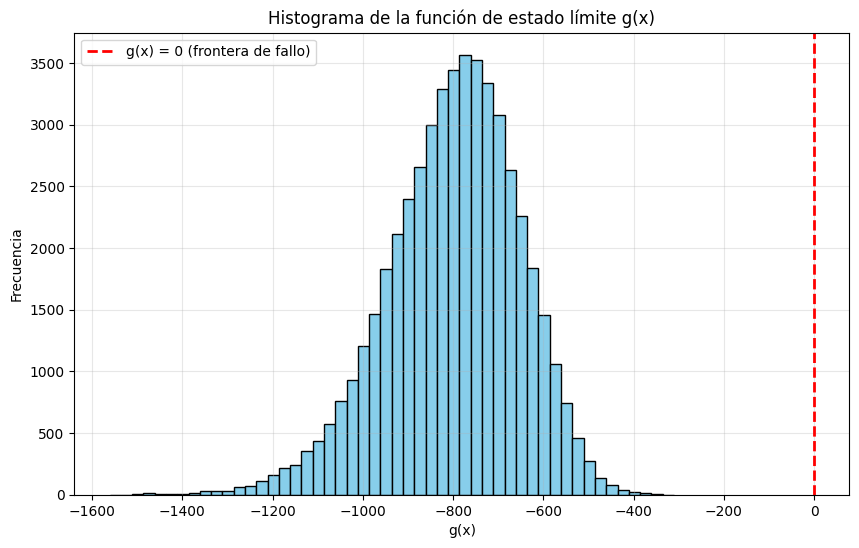

In [24]:
# ============================================================
# 6. Histograma de g(x)
# ============================================================

#g = results.g

plt.figure(figsize=(10,6))
plt.hist(g, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='g(x) = 0 (frontera de fallo)')
plt.title('Histograma de la función de estado límite g(x)')
plt.xlabel('g(x)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Representamos convergencia de la probabilidad de fallo

En esta grafica se identifica las simulaciones que son fallo g_fail = g < 0 con valores 
      True la simulación ha fallado
      False la simulación es segura.
          
La curva morada muestra cómo va cambiando la estimación de la probabilidad de fallo (pf) a medida que aumentan las simulaciones Monte Carlo.

La línea roja es el valor final de la probabilidad de fallo (pf) cuando ya se han realizado todas las simulaciones y la curva morada debe acercarse a ella si la simulación está bien hecha.
    

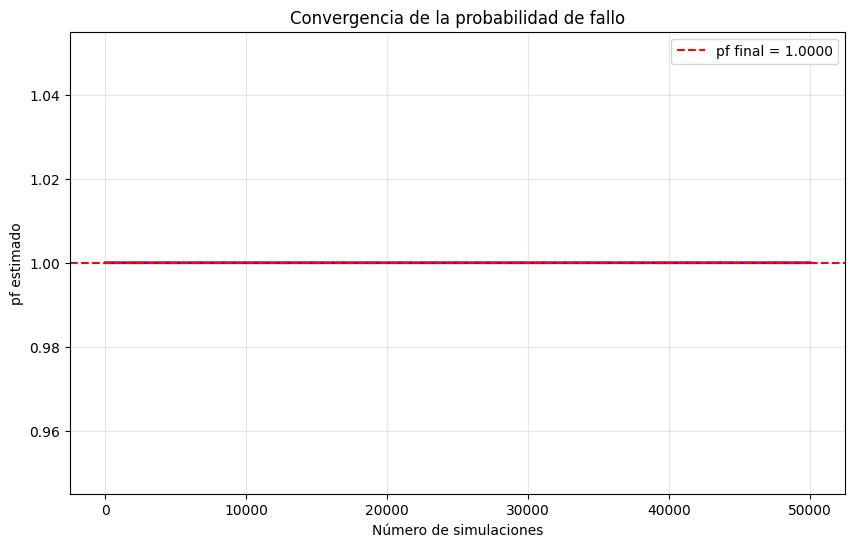

In [25]:
# ============================================================
# 7. Convergencia de la probabilidad de fallo
# ============================================================

g_fail = g < 0
pf_convergence = np.cumsum(g_fail) / np.arange(1, N+1)

plt.figure(figsize=(10,6))

plt.plot(pf_convergence, color='purple', linewidth=2)
plt.axhline(pf, color='red', linestyle='--', label=f'pf final = {pf:.4f}')
plt.title('Convergencia de la probabilidad de fallo')
plt.xlabel('Número de simulaciones')
plt.ylabel('pf estimado')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Conclusión
En este ejercicio he realizado un análisis de fiabilidad estructural utilizando el método de simulación Monte Carlo. Aunque la versión actual de PySTRA ha cambiado y ya no incluye las clases empleadas en los ejemplos originales, he podido reproducir el procedimiento completo apoyándome en NumPy y SciPy, que son las bases científicas sobre las que se construye esta librería.

Al igual que en el modelo que se presenta en el artículo, El enfoque seguido mantiene la misma lógica que aparece en la documentación clásica de PySTRA. En primer lugar, se definen las variables aleatorias que representan la incertidumbre del problema. Después, se formula la función de estado límite, que permite distinguir cuándo la estructura se encuentra en condiciones seguras y cuándo podría fallar.

En este caso concreto, el modelo utiliza tres parámetros esenciales: el módulo de Young, la carga aplicada y el área de la sección. A partir de ellos se calcula la función g(x), que indica si la barra soporta la carga o si entra en fallo. La simulación Monte Carlo permite obtener la distribución de esta función, estimar la probabilidad de fallo y calcular el índice de fiabilidad β, que es una medida habitual en ingeniería para evaluar la seguridad de un sistema.

Además, este tipo de análisis es fácilmente ampliable. Igual que ocurre con PySTRA, se podrían incorporar distribuciones más complejas, relaciones entre variables o modelos estructurales de mayor detalle. El uso de bibliotecas científicas de Python facilita también la visualización de resultados y la integración con otros métodos de análisis.

En conjunto, el ejercicio muestra que, incluso con los cambios recientes en PySTRA, es posible mantener la esencia del análisis probabilístico y obtener resultados claros, reproducibles y válidos tanto en el ámbito académico como en aplicaciones reales de ingeniería.

## Declaración uso IA

Se han utilizado herramientas de IA generativa para poder reproducir el método de simulación Monte Carlo descrito en la documentación técnica de PySTRA, debido a que la librería ha cambiado y ya no incluye las clases del ejemplo original.